In [1]:
import json
import os
import pandas as pd
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

print("🚀 Loading CLIP Bouncer Model...")
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def is_pie_chart(image_path):
    """Uses CLIP to instantly detect if an image is a pie chart."""
    try:
        image = Image.open(image_path).convert("RGB")
        labels = ["a photo of a pie chart", "a photo of a bar chart, line chart, or scatter plot"]
        inputs = clip_processor(text=labels, images=image, return_tensors="pt", padding=True).to(device)
        
        with torch.no_grad():
            outputs = clip_model(**inputs)
            probs = outputs.logits_per_image.softmax(dim=1).cpu().numpy()[0]
        
        return probs[0] > probs[1] # Returns True if it thinks it's a pie chart
    except Exception:
        return False # If image is corrupted, just let the next steps handle/skip it

def process_dataset_split(split_name, figureqa_folder_name):
    print(f"\n{'='*50}")
    print(f"🔥 STARTING SPLIT: {split_name.upper()}")
    print(f"{'='*50}")

    # --- 1. CONFIGURATION PATHS ---
    # Adapting paths based on the split name!
    figureqa_dir = f"./../FigureQA_Dataset/{figureqa_folder_name}"
    chartqa_dir = f"./../ChartQA_Dataset/{split_name}"
    plotqa_dir = f"./../PlotQA_Dataset/{split_name}"

    master_dataset = []

    # --- 2. PARSE FIGUREQA ---
    print(f"\n--- Parsing FigureQA ({split_name}) ---")
    if not os.path.exists(figureqa_dir):
        print(f"❌ ERROR: Could not find folder -> {figureqa_dir}")
    else:
        anno_path = os.path.join(figureqa_dir, 'annotations.json')
        if not os.path.exists(anno_path):
            print(f"❌ ERROR: Found folder, but no annotations.json -> {anno_path}")
        else:
            with open(anno_path, 'r') as f:
                figureqa_data = json.load(f)
            
            found_count = 0
            for item in figureqa_data:
                img_path = os.path.join(figureqa_dir, "png", f"{item['image_index']}.png")
                if not os.path.exists(img_path): continue
                    
                if item['type'] in ['vbar_categorical', 'hbar_categorical', 'line', 'dot_line']:
                    markdown_str = "TITLE | Unknown <0x0A> X_Label | Y_Label"
                    for model in item['models']:
                        x_values = model.get('x', [])
                        y_values = model.get('y', [])
                        if not isinstance(x_values, list): x_values = [x_values]
                        if not isinstance(y_values, list): y_values = [y_values]
                        for i in range(min(len(x_values), len(y_values))):
                            try:
                                y_val = round(float(y_values[i]), 2)
                            except (TypeError, ValueError):
                                y_val = y_values[i]
                            markdown_str += f" <0x0A> {x_values[i]} | {y_val}"
                            
                    master_dataset.append({"image_path": img_path, "target_text": markdown_str})
                    found_count += 1
            print(f"✅ Successfully extracted {found_count} charts from FigureQA!")

    # --- 3. PARSE CHARTQA ---
    print(f"\n--- Parsing ChartQA ({split_name}) ---")
    if not os.path.exists(chartqa_dir):
        print(f"❌ ERROR: Could not find folder -> {chartqa_dir}")
    else:
        chartqa_img_dir = os.path.join(chartqa_dir, "png")
        chartqa_csv_dir = os.path.join(chartqa_dir, "tables")
        
        if not os.path.exists(chartqa_img_dir) or not os.path.exists(chartqa_csv_dir):
             print(f"❌ ERROR: Missing 'png' or 'tables' subfolder inside {chartqa_dir}")
        else:
            found_count = 0
            skipped_pies = 0
            for img_file in os.listdir(chartqa_img_dir):
                if img_file.endswith(".png"):
                    base_name = img_file.replace(".png", "")
                    img_path = os.path.join(chartqa_img_dir, img_file)
                    csv_path = os.path.join(chartqa_csv_dir, f"{base_name}.csv")
                    
                    if os.path.exists(csv_path):
                        # ⚡ THE BOUNCER: Check if it's a Pie Chart!
                        if is_pie_chart(img_path):
                            skipped_pies += 1
                            continue
                            
                        try:
                            df = pd.read_csv(csv_path)
                            headers = " | ".join(df.columns)
                            markdown_str = f"TITLE | Unknown <0x0A> {headers}"
                            for index, row in df.iterrows():
                                row_str = " | ".join([str(val) for val in row.values])
                                markdown_str += f" <0x0A> {row_str}"
                                
                            master_dataset.append({"image_path": img_path, "target_text": markdown_str})
                            found_count += 1
                        except Exception:
                            pass # Skip corrupted CSVs
            print(f"✅ Extracted {found_count} Bar/Line charts. 🚫 Bouncer skipped {skipped_pies} Pie charts!")

    # --- 4. PARSE PLOTQA ---
    print(f"\n--- Parsing PlotQA ({split_name}) ---")
    if not os.path.exists(plotqa_dir):
        print(f"❌ ERROR: Could not find folder -> {plotqa_dir}")
    else:
        anno_path = os.path.join(plotqa_dir, 'annotations.json')
        if not os.path.exists(anno_path):
            print(f"❌ ERROR: Found folder, but no annotations.json -> {anno_path}")
        else:
            with open(anno_path, 'r') as f:
                plotqa_data = json.load(f)

            found_count = 0
            for item in plotqa_data:
                img_path = os.path.join(plotqa_dir, "png", f"{item['image_index']}.png")
                if not os.path.exists(img_path): continue
                    
                if item['type'] in ['vbar_categorical', 'hbar_categorical', 'line', 'dot_line']:
                    markdown_str = "TITLE | Unknown <0x0A> X_Label | Y_Label"
                    for model in item['models']:
                        x_values = model.get('x', [])
                        y_values = model.get('y', [])
                        if not isinstance(x_values, list): x_values = [x_values]
                        if not isinstance(y_values, list): y_values = [y_values]
                        for i in range(min(len(x_values), len(y_values))):
                            try:
                                y_val = round(float(y_values[i]), 2)
                            except (TypeError, ValueError):
                                y_val = y_values[i]
                            markdown_str += f" <0x0A> {x_values[i]} | {y_val}"
                            
                    master_dataset.append({"image_path": img_path, "target_text": markdown_str})
                    found_count += 1
            print(f"✅ Successfully extracted {found_count} charts from PlotQA!")

    # --- 5. SAVE JSONL ---
    print(f"\n--- Finishing Up {split_name.upper()} ---")
    output_file = f"master_dataset_{split_name}.jsonl"
    print(f"Saving {len(master_dataset)} total charts to {output_file}...")

    with open(output_file, 'w') as f:
        for entry in master_dataset:
            f.write(json.dumps(entry) + '\n')

    if len(master_dataset) > 0:
        print(f"✅ {split_name.upper()} Dataset Created Successfully!")
    else:
        print(f"⚠️ {split_name.upper()} Dataset is empty.")


# ==========================================
# EXECUTE FOR BOTH SPLITS
# (FigureQA uses 'train1' and 'val1' for folder names)
# ==========================================
# process_dataset_split(split_name="train", figureqa_folder_name="train1")
process_dataset_split(split_name="val", figureqa_folder_name="validation1")

/Users/aryangahlot/.pyenv/versions/tfenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Loading CLIP Bouncer Model...


Loading weights: 100%|███████████████████████████████████████████████████| 398/398 [00:00<00:00, 1938.79it/s, Materializing param=visual_projection.weight]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 



🔥 STARTING SPLIT: VAL

--- Parsing FigureQA (val) ---
✅ Successfully extracted 16000 charts from FigureQA!

--- Parsing ChartQA (val) ---
✅ Extracted 946 Bar/Line charts. 🚫 Bouncer skipped 110 Pie charts!

--- Parsing PlotQA (val) ---
✅ Successfully extracted 33650 charts from PlotQA!

--- Finishing Up VAL ---
Saving 50596 total charts to master_dataset_val.jsonl...
✅ VAL Dataset Created Successfully!


In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "2" # Limits CPU core usage
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0" # Prevents RAM hoarding
import time # We need this for the cool-down hack

In [4]:
import json
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import shutil

# --- 1. CONFIGURATION ---
SPLIT = "val"  # Change this to "val" and run again for validation data

# Update these paths to point to your local dataset split folders
# Note: FigureQA often uses 'train1' and 'val1'
datasets = {
    "FigureQA": f"./../FigureQA_Dataset/{SPLIT}1",
    "ChartQA": f"./../ChartQA_Dataset/{SPLIT}",
    "PlotQA": f"./../PlotQA_Dataset/{SPLIT}"
}

# Create YOLO-standard directory structure
output_images_dir = f"./yolo_dataset/images/{SPLIT}"
output_labels_dir = f"./yolo_dataset/labels/{SPLIT}"
os.makedirs(output_images_dir, exist_ok=True)
os.makedirs(output_labels_dir, exist_ok=True)

CLASS_BAR = 0

def process_and_copy(img_path, bboxes, out_img_dir, out_lab_dir):
    """Normalizes labels AND copies the image to the YOLO folder"""
    if not os.path.exists(img_path): return
    
    try:
        with Image.open(img_path) as img:
            w_img, h_img = img.size
        
        yolo_lines = []
        for box in bboxes:
            if isinstance(box, dict):
                x, y, w, h = box['x'], box['y'], box['w'], box['h']
            else:
                x, y, w, h = box
                
            cx, cy = (x + w/2) / w_img, (y + h/2) / h_img
            nw, nh = w / w_img, h / h_img
            yolo_lines.append(f"{CLASS_BAR} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        if yolo_lines:
            base_name = os.path.basename(img_path)
            # Copy Image
            shutil.copy(img_path, os.path.join(out_img_dir, base_name))
            # Save Label
            txt_filename = base_name.rsplit('.', 1)[0] + ".txt"
            with open(os.path.join(out_lab_dir, txt_filename), 'w') as f:
                f.write("\n".join(yolo_lines))
    except: return

# --- 2. PROCESSING ---

# A. FIGUREQA & PLOTQA
for name in ["FigureQA", "PlotQA"]:
    print(f"\nProcessing {name} [{SPLIT}]...")
    base_dir = datasets[name]
    anno_path = os.path.join(base_dir, "annotations.json")
    
    if os.path.exists(anno_path):
        with open(anno_path, 'r') as f:
            data = json.load(f)
        for item in tqdm(data, desc=f"Extracting {name}"):
            if item['type'] in ['vbar_categorical', 'hbar_categorical']:
                img_path = os.path.join(base_dir, "png", f"{item['image_index']}.png")
                all_boxes = []
                for model in item['models']:
                    if 'bboxes' in model: all_boxes.extend(model['bboxes'])
                process_and_copy(img_path, all_boxes, output_images_dir, output_labels_dir)

# B. CHARTQA
print(f"\nProcessing ChartQA [{SPLIT}]...")
chart_base = datasets["ChartQA"]
chart_anno_dir = os.path.join(chart_base, "annotations")

if os.path.exists(chart_anno_dir):
    anno_files = [f for f in os.listdir(chart_anno_dir) if f.endswith('.json')]
    for filename in tqdm(anno_files, desc="Extracting ChartQA"):
        with open(os.path.join(chart_anno_dir, filename), 'r') as f:
            item = json.load(f)
        if item.get('type') in ['v_bar', 'h_bar', 'vbar_categorical', 'hbar_categorical']:
            img_path = os.path.join(chart_base, "png", filename.replace('.json', '.png'))
            all_boxes = []
            for model in item.get('models', []):
                if 'bboxes' in model: all_boxes.extend(model['bboxes'])
            process_and_copy(img_path, all_boxes, output_images_dir, output_labels_dir)

print(f"\n✅ YOLO {SPLIT.upper()} set generated!")


Processing FigureQA [val]...

Processing PlotQA [val]...


Extracting PlotQA: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 33650/33650 [00:13<00:00, 2548.64it/s]



Processing ChartQA [val]...


Extracting ChartQA: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 1056/1056 [00:00<00:00, 1551.81it/s]


✅ YOLO VAL set generated!


In [4]:
import json
import os
import shutil
from PIL import Image
from tqdm import tqdm

# Define datasets and their splits
# Adjust these paths if your validation folders are named differently
dataset_configs = [
    {"name": "FigureQA", "base": "./../FigureQA_Dataset/train1", "split": "train"},
    {"name": "FigureQA", "base": "./../FigureQA_Dataset/validation1", "split": "val"},
    {"name": "PlotQA", "base": "./../PlotQA_Dataset/train", "split": "train"},
    {"name": "PlotQA", "base": "./../PlotQA_Dataset/val", "split": "val"}
]

CLASS_BAR = 0  

def process_and_copy(img_path, bboxes, split):
    out_img_dir = f"./datasets/yolo_dataset_bar/images/{split}"
    out_lab_dir = f"./datasets/yolo_dataset_bar/labels/{split}"
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lab_dir, exist_ok=True)

    if not os.path.exists(img_path): return
    try:
        with Image.open(img_path) as img:
            w_img, h_img = img.size
        
        yolo_lines = []
        for box in bboxes:
            # Handle different coordinate formats
            if isinstance(box, dict):
                x, y, w, h = box['x'], box['y'], box['w'], box['h']
            else:
                x, y, w, h = box
                
            # Normalize to YOLO format (0-1)
            cx, cy = (x + w/2) / w_img, (y + h/2) / h_img
            nw, nh = w / w_img, h / h_img
            yolo_lines.append(f"{CLASS_BAR} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        if yolo_lines:
            base_name = os.path.basename(img_path)
            shutil.copy(img_path, os.path.join(out_img_dir, base_name))
            
            txt_filename = base_name.rsplit('.', 1)[0] + ".txt"
            with open(os.path.join(out_lab_dir, txt_filename), 'w') as f:
                f.write("\n".join(yolo_lines))
    except:
        pass

# Execute Strict Extraction for all configs
for config in dataset_configs:
    print(f"\nProcessing {config['name']} ({config['split']})...")
    anno_path = os.path.join(config['base'], "annotations.json")
    
    if os.path.exists(anno_path):
        with open(anno_path, 'r') as f:
            data = json.load(f)
            
        for item in tqdm(data):
            # STRICT FILTER: Only vbar and hbar
            if item['type'] in ['vbar_categorical', 'hbar_categorical']:
                img_path = os.path.join(config['base'], "png", f"{item['image_index']}.png")
                all_boxes = []
                for model in item['models']:
                    if 'bboxes' in model: 
                        all_boxes.extend(model['bboxes'])
                
                process_and_copy(img_path, all_boxes, config['split'])

print("\n✅ Clean Train & Val datasets generated! No more ChartQA noise.")


Processing FigureQA (train)...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:22<00:00, 4401.60it/s]



Processing FigureQA (val)...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [00:03<00:00, 5160.65it/s]



Processing PlotQA (train)...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 157070/157070 [00:07<00:00, 20954.73it/s]



Processing PlotQA (val)...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33650/33650 [00:13<00:00, 2414.23it/s]


✅ Clean Train & Val datasets generated! No more ChartQA noise.


In [1]:
import json
import os
import shutil
from PIL import Image
from tqdm import tqdm

# Define datasets and their splits
dataset_configs = [
    {"name": "FigureQA", "base": "./../FigureQA_Dataset/train1", "split": "train"},
    {"name": "FigureQA", "base": "./../FigureQA_Dataset/validation1", "split": "val"},
    {"name": "PlotQA", "base": "./../PlotQA_Dataset/train", "split": "train"},
    {"name": "PlotQA", "base": "./../PlotQA_Dataset/val", "split": "val"}
]

CLASS_BAR = 0  

def process_and_copy(img_path, bboxes, split, chart_type):
    out_img_dir = f"./datasets/yolo_dataset_bar/images/{split}"
    out_lab_dir = f"./datasets/yolo_dataset_bar/labels/{split}"
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lab_dir, exist_ok=True)

    if not os.path.exists(img_path): return
    
    try:
        with Image.open(img_path) as img:
            w_img, h_img = img.size
        
        yolo_lines = []
        for box in bboxes:
            # --- 1. THE FORMAT FIX ---
            if isinstance(box, dict):
                # FigureQA format gives us exact width and height
                x, y, w, h = box['x'], box['y'], box['w'], box['h']
            else:
                # PlotQA format gives us [x_min, y_min, x_max, y_max]
                x1, y1, x2, y2 = box
                x = x1
                y = y1
                w = x2 - x1  # Calculate the true width!
                h = y2 - y1  # Calculate the true height!
                
            # --- 2. THE GEOMETRIC FLIP FIX ---
            if chart_type == 'vbar_categorical' and w > h:
                w, h = h, w
            elif chart_type == 'hbar_categorical' and h > w:
                w, h = h, w
                
            # Normalize to YOLO format (0-1)
            cx, cy = (x + w/2) / w_img, (y + h/2) / h_img
            nw, nh = w / w_img, h / h_img
            yolo_lines.append(f"{CLASS_BAR} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        # Save files only if we found valid boxes
        if yolo_lines:
            base_name = os.path.basename(img_path)
            shutil.copy(img_path, os.path.join(out_img_dir, base_name))
            
            txt_filename = base_name.rsplit('.', 1)[0] + ".txt"
            with open(os.path.join(out_lab_dir, txt_filename), 'w') as f:
                f.write("\n".join(yolo_lines))
                
    except Exception as e:
        pass

# Execute Strict Extraction for all configs
for config in dataset_configs:
    print(f"\nProcessing {config['name']} ({config['split']})...")
    anno_path = os.path.join(config['base'], "annotations.json")
    
    if os.path.exists(anno_path):
        with open(anno_path, 'r') as f:
            data = json.load(f)
            
        for item in tqdm(data):
            # STRICT FILTER: Only vbar and hbar
            if item['type'] in ['vbar_categorical', 'hbar_categorical']:
                img_path = os.path.join(config['base'], "png", f"{item['image_index']}.png")
                all_boxes = []
                
                for model in item['models']:
                    if 'bboxes' in model: 
                        all_boxes.extend(model['bboxes'])
                
                # Pass the chart_type to the function so it knows how to orient the boxes
                process_and_copy(img_path, all_boxes, config['split'], item['type'])

print("\n✅ Clean Train & Val datasets generated! Formatting and geometric bugs eliminated.")


Processing FigureQA (train)...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:19<00:00, 5065.59it/s]



Processing FigureQA (val)...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [00:03<00:00, 5163.74it/s]



Processing PlotQA (train)...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 157070/157070 [00:07<00:00, 19863.95it/s]



Processing PlotQA (val)...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33650/33650 [00:13<00:00, 2467.82it/s]


✅ Clean Train & Val datasets generated! Formatting and geometric bugs eliminated.


In [14]:
import json
import os
import shutil
from PIL import Image
from tqdm import tqdm

dataset_configs = [
    {"name": "FigureQA", "base": "./../FigureQA_Dataset/train1", "split": "train"},
    {"name": "FigureQA", "base": "./../FigureQA_Dataset/validation1", "split": "val"},
    {"name": "PlotQA", "base": "./../PlotQA_Dataset/train", "split": "train"},
    {"name": "PlotQA", "base": "./../PlotQA_Dataset/val", "split": "val"}
]

CLASS_BAR = 0  

def process_and_copy(img_path, bboxes, split):
    out_img_dir = f"./datasets/yolo_dataset_bar/images/{split}"
    out_lab_dir = f"./datasets/yolo_dataset_bar/labels/{split}"
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lab_dir, exist_ok=True)

    if not os.path.exists(img_path): return
    
    try:
        with Image.open(img_path) as img:
            w_img, h_img = img.size
        
        yolo_lines = []
        for box in bboxes:
            # Reverted to pure, original extraction. No bad math.
            if isinstance(box, dict):
                x, y, w, h = box['x'], box['y'], box['w'], box['h']
            else:
                x, y, w, h = box 
                    
            # Normalize to YOLO format (0-1)
            cx, cy = (x + w/2) / w_img, (y + h/2) / h_img
            nw, nh = w / w_img, h / h_img
            yolo_lines.append(f"{CLASS_BAR} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        if yolo_lines:
            base_name = os.path.basename(img_path)
            shutil.copy(img_path, os.path.join(out_img_dir, base_name))
            
            txt_filename = base_name.rsplit('.', 1)[0] + ".txt"
            with open(os.path.join(out_lab_dir, txt_filename), 'w') as f:
                f.write("\n".join(yolo_lines))
                
    except Exception as e:
        pass

# Execute Extraction with Quarantine
for config in dataset_configs:
    print(f"\nProcessing {config['name']} ({config['split']})...")
    anno_path = os.path.join(config['base'], "annotations.json")
    is_plotqa = "PlotQA" in config['name']
    
    if os.path.exists(anno_path):
        with open(anno_path, 'r') as f:
            data = json.load(f)
            
        for item in tqdm(data):
            if item['type'] in ['vbar_categorical', 'hbar_categorical']:
                
                # --- THE PLOTQA QUARANTINE FILTER ---
                # PlotQA grouped charts (attached bars) have corrupted coordinates.
                # We skip them entirely. FigureQA grouped charts are kept.
                if is_plotqa and len(item['models']) > 1:
                    continue 
                # ------------------------------------
                
                img_path = os.path.join(config['base'], "png", f"{item['image_index']}.png")
                all_boxes = []
                
                for model in item['models']:
                    if 'bboxes' in model: 
                        all_boxes.extend(model['bboxes'])
                
                process_and_copy(img_path, all_boxes, config['split'])

print("\n✅ Pristine Dataset Generated! Corrupted PlotQA attached bars have been quarantined.")


Processing FigureQA (train)...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:20<00:00, 4815.88it/s]



Processing FigureQA (val)...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [00:03<00:00, 5107.04it/s]



Processing PlotQA (train)...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 157070/157070 [00:01<00:00, 148725.05it/s]



Processing PlotQA (val)...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33650/33650 [00:02<00:00, 13894.84it/s]


✅ Pristine Dataset Generated! Corrupted PlotQA attached bars have been quarantined.


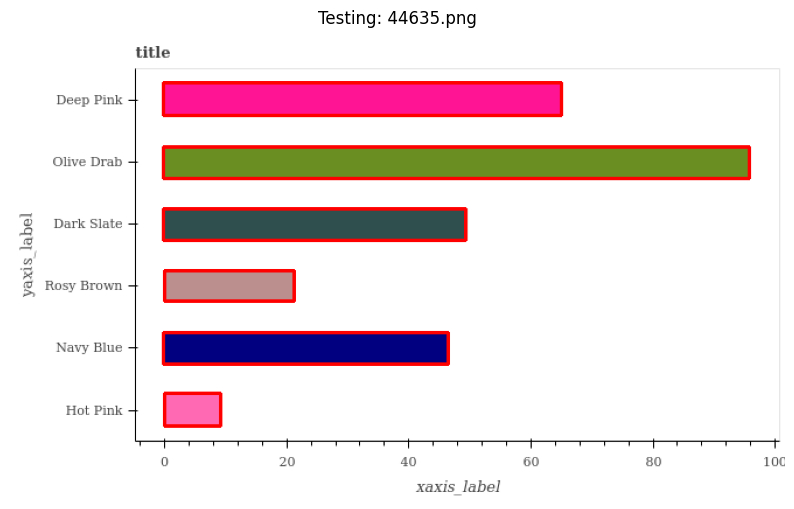

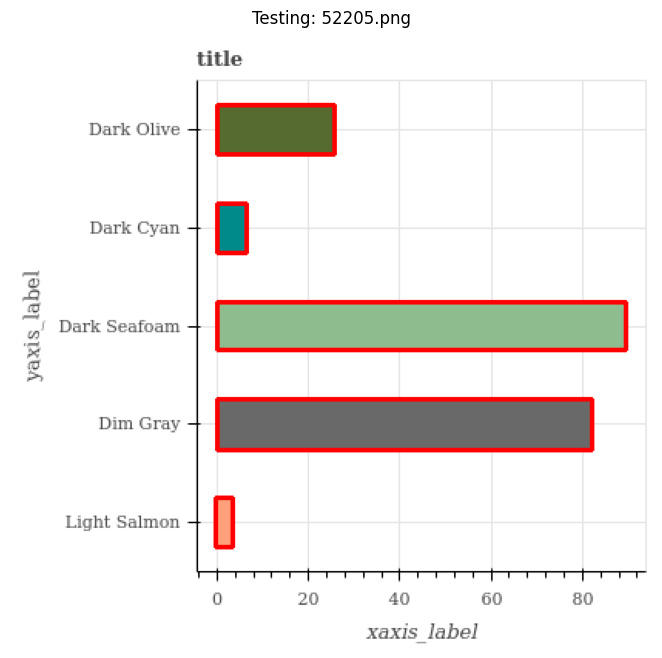

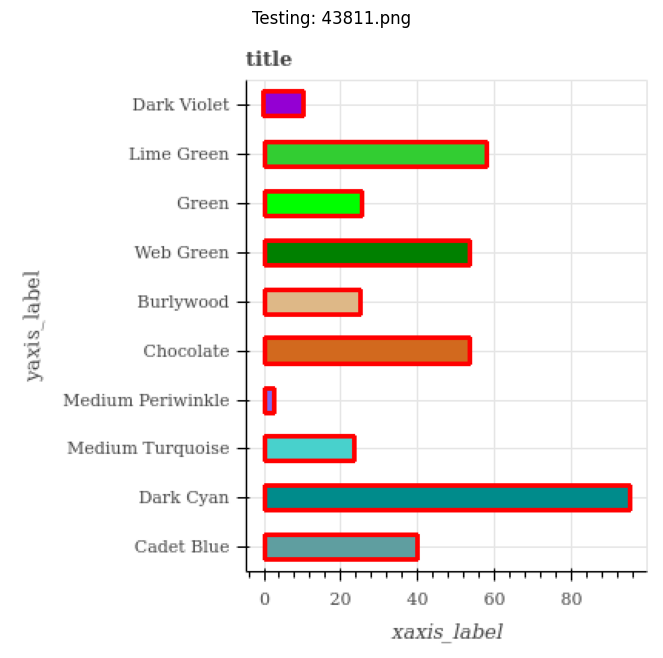

In [26]:
import cv2
import os
import random
import matplotlib.pyplot as plt

def test_yolo_labels(img_dir, label_dir, num_samples=3):
    # Get all images in the directory
    if not os.path.exists(img_dir):
        print(f"Error: Directory {img_dir} not found.")
        return
        
    images = [f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg'))]
    
    if not images:
        print("No images found to test.")
        return
    
    # Pick random samples
    samples = random.sample(images, min(num_samples, len(images)))
    
    for sample_img in samples:
        sample_label = sample_img.rsplit('.', 1)[0] + '.txt'
        img_path = os.path.join(img_dir, sample_img)
        label_path = os.path.join(label_dir, sample_label)
        
        if not os.path.exists(label_path):
            print(f"Skipping {sample_img} - No label found")
            continue

        # Read image and convert color for matplotlib
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        # Read label and draw boxes
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.split()
                if len(parts) < 5: continue
                
                # YOLO format: class cx cy nw nh
                cx, cy, nw, nh = map(float, parts[1:5])
                
                # Convert normalized YOLO coordinates back to exact pixels
                x1 = int((cx - nw/2) * w)
                y1 = int((cy - nh/2) * h)
                x2 = int((cx + nw/2) * w)
                y2 = int((cy + nh/2) * h)
                
                # Draw a bright red box with a thickness of 2
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

        # Show the image
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.title(f"Testing: {sample_img}")
        plt.axis('off')
        plt.show()

# Set paths to your clean dataset
images_path = './datasets/yolo_dataset_bar/images/train'
labels_path = './datasets/yolo_dataset_bar/labels/train'

# Run the test! (Change num_samples to see more images)
test_yolo_labels(images_path, labels_path, num_samples=3)


🔍 Testing Model on: 11176.png

image 1/1 /Users/aryangahlot/Desktop/Coding/AI-ML/Spectra/notebooks/datasets/yolo_dataset_bar/images/val/11176.png: 512x640 2 bars, 25.0ms
Speed: 0.9ms preprocess, 25.0ms inference, 0.3ms postprocess per image at shape (1, 3, 512, 640)


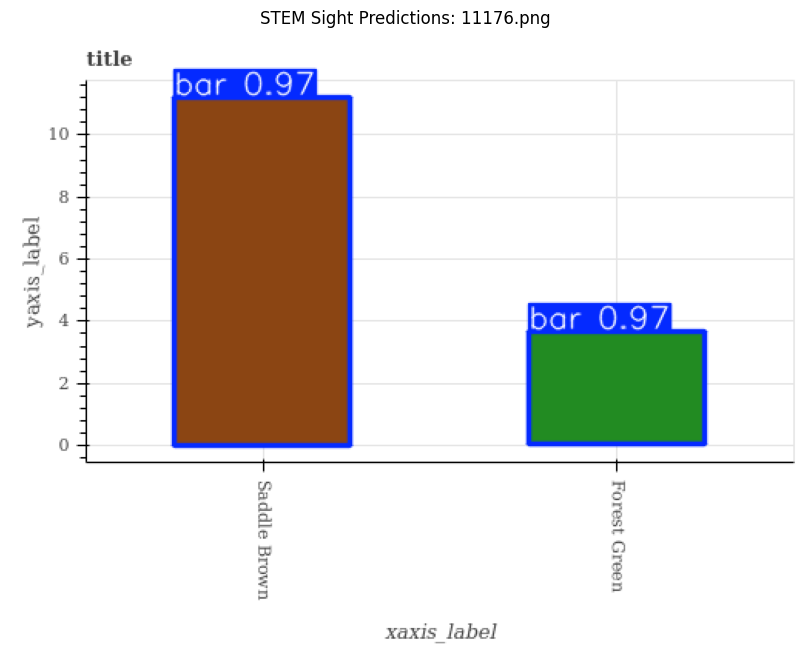


🔍 Testing Model on: 12624.png

image 1/1 /Users/aryangahlot/Desktop/Coding/AI-ML/Spectra/notebooks/datasets/yolo_dataset_bar/images/val/12624.png: 608x640 8 bars, 30.3ms
Speed: 0.9ms preprocess, 30.3ms inference, 0.3ms postprocess per image at shape (1, 3, 608, 640)


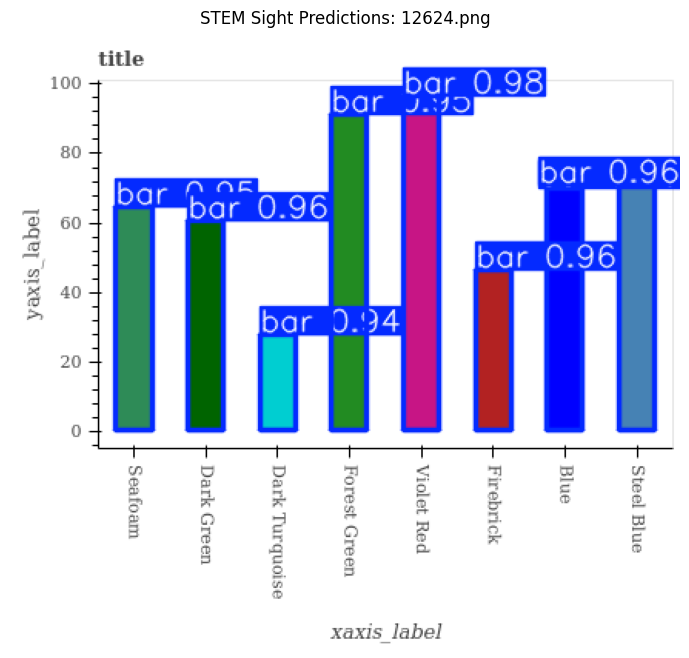


🔍 Testing Model on: 16682.png

image 1/1 /Users/aryangahlot/Desktop/Coding/AI-ML/Spectra/notebooks/datasets/yolo_dataset_bar/images/val/16682.png: 448x640 3 bars, 21.4ms
Speed: 0.9ms preprocess, 21.4ms inference, 0.2ms postprocess per image at shape (1, 3, 448, 640)


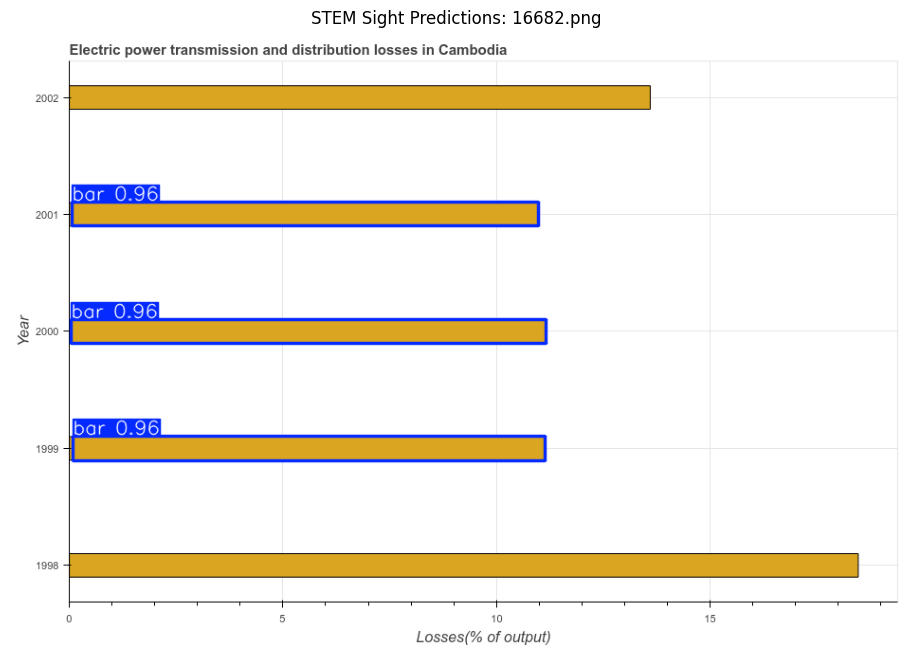

In [6]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load your newly trained "best" weights
# Update this path to wherever your downloaded best.pt is saved
model_path = "./train2/weights/best.pt" 
model = YOLO(model_path)

# 2. Point this to your clean validation images (or any random charts you download from Google)
test_images_dir = "./datasets/yolo_dataset_bar/images/val"

def test_random_chart(num_tests=3):
    all_images = [f for f in os.listdir(test_images_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    if not all_images:
        print("❌ No images found in the directory!")
        return
        
    # Pick a few random samples
    samples = random.sample(all_images, min(num_tests, len(all_images)))
    
    for sample_img in samples:
        img_path = os.path.join(test_images_dir, sample_img)
        print(f"\n🔍 Testing Model on: {sample_img}")
        
        # --- THE INFERENCE STEP ---
        # conf=0.5 means the model only draws boxes it is 50%+ confident about
        results = model(img_path, conf=0.5) 
        
        # YOLO automatically draws the predicted bounding boxes and confidences!
        annotated_img = results[0].plot() 
        
        # Convert BGR (OpenCV format) to RGB (Matplotlib format)
        annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
        
        # Display the result
        plt.figure(figsize=(12, 8))
        plt.imshow(annotated_img_rgb)
        plt.title(f"STEM Sight Predictions: {sample_img}")
        plt.axis('off')
        plt.show()

# Run the test! 
test_random_chart(num_tests=3)

🔍 Analyzing: ./Real_Test_Graph/hbar2.png

image 1/1 /Users/aryangahlot/Desktop/Coding/AI-ML/Spectra/notebooks/Real_Test_Graph/hbar2.png: 896x1024 15 bars, 68.0ms
Speed: 2.7ms preprocess, 68.0ms inference, 0.5ms postprocess per image at shape (1, 3, 896, 1024)


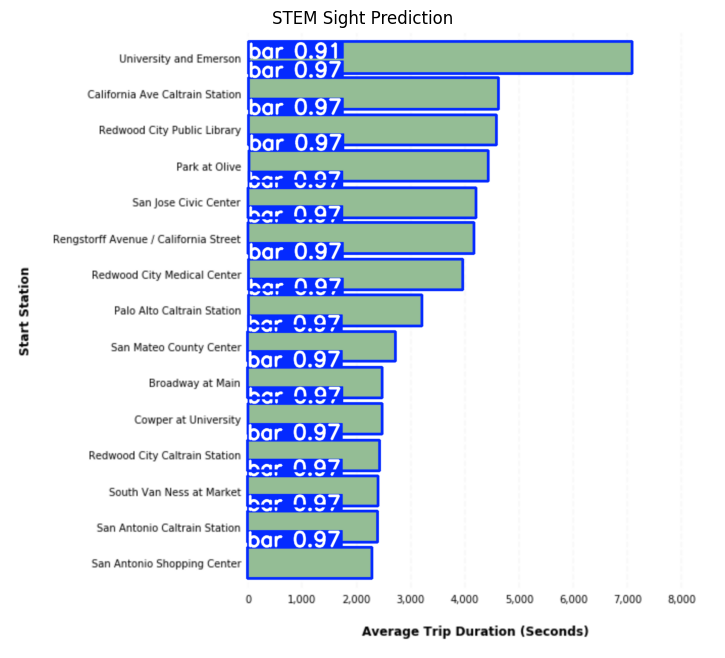

In [17]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

# 1. Load your trained model (You only need to run this line once)
model_path = "./train2/weights/best.pt" 
model = YOLO(model_path)

def test_single_chart(image_path, confidence=0.5):
    if not os.path.exists(image_path):
        print(f"❌ Error: Could not find image at {image_path}")
        return

    print(f"🔍 Analyzing: {image_path}")
    
    # --- THE INFERENCE STEP ---
    # Run the model on your specific image
    results = model(image_path, conf=0.8, imgsz=1024)
    
    # Extract the image with the predicted boxes drawn on it
    annotated_img = results[0].plot() 
    
    # Convert from BGR (OpenCV) to RGB (Matplotlib) so colors look correct
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    # Display the result beautifully
    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_img_rgb)
    plt.title("STEM Sight Prediction")
    plt.axis('off')
    plt.show()

# ==========================================
# 👇 PASTE YOUR IMAGE PATH HERE 👇
# ==========================================
my_image_path = "./Real_Test_Graph/hbar2.png" 

# Run the test!
test_single_chart(my_image_path)

In [25]:
import torch
import torchvision.transforms as transforms
from torchvision import models

# ==========================================
# 1. LOAD THE CLASSIFIER (Chart Type)
# ==========================================
classifier = models.resnet18() 
num_ftrs = classifier.fc.in_features

# --- THE FIX ---
# Your saved weights expect 5 output classes, not 2!
classifier.fc = torch.nn.Linear(num_ftrs, 5)  

# Now it will load perfectly
classifier.load_state_dict(torch.load('graph_classifier_real.pth', map_location='cpu'))
classifier.eval()

# --- CRITICAL STEP ---
# You must update this list to match the EXACT order of the 5 classes you used during training!
# I am guessing based on the dataset, but if this order is wrong, it will call a pie chart a bar chart.
CLASS_NAMES = ['vbar_categorical', 'hbar_categorical', 'line', 'pie', 'dot_line']

# Standard image transformation for PyTorch classifiers
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ==========================================
# 2. LOAD YOLO (Bar Detector)
# ==========================================
yolo_model = YOLO("./train2/weights/best.pt")

# ==========================================
# 3. THE EXTRACTION PIPELINE
# ==========================================
def extract_chart_data(image_path):
    print(f"\n🚀 Processing: {image_path}")
    
    # --- STEP A: Classify the Chart ---
    img_pil = Image.open(image_path).convert('RGB')
    img_tensor = transform(img_pil).unsqueeze(0)
    
    with torch.no_grad():
        outputs = classifier(img_tensor)
        _, predicted = torch.max(outputs, 1)
        chart_type = CLASS_NAMES[predicted.item()]
        
    print(f"📊 Chart Type Detected: {chart_type.upper()}")

    # --- STEP B: Detect the Bars (Lowered conf/imgsz for accuracy) ---
    results = yolo_model(image_path, conf=0.8, imgsz=1024, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy() # [x1, y1, x2, y2]
    
    if len(boxes) == 0:
        print("❌ No bars detected in this image.")
        return []

    # --- STEP C: Mathematical Extraction & Sorting ---
    extracted_data = []
    
    # Use 'in' to catch both 'hbar' and 'hbar_categorical' safely
    if 'vbar' in chart_type.lower():
        print("📏 Extracting Vertical Bar Heights...")
        # Vertical: Sort left-to-right (by x1)
        sorted_boxes = sorted(boxes, key=lambda b: b[0])
        for idx, box in enumerate(sorted_boxes):
            x1, y1, x2, y2 = box
            pixel_height = y2 - y1
            extracted_data.append(pixel_height)
            print(f"  Bar {idx+1} (Left-to-Right): {pixel_height:.1f} pixels tall")
            
    elif 'hbar' in chart_type.lower():
        print("📏 Extracting Horizontal Bar Widths...")
        # Horizontal: Sort top-to-bottom (by y1)
        sorted_boxes = sorted(boxes, key=lambda b: b[1])
        for idx, box in enumerate(sorted_boxes):
            x1, y1, x2, y2 = box
            pixel_width = x2 - x1
            extracted_data.append(pixel_width)
            print(f"  Bar {idx+1} (Top-to-Bottom): {pixel_width:.1f} pixels wide")
            
    else:
        print(f"⚠️ YOLO extraction is currently only for bars. Detected: {chart_type}")

    return extracted_data

# Run it on your test image!
my_image = "./Real_Test_Graph/hbar2.png" 
pixel_values = extract_chart_data(my_image)


🚀 Processing: ./Real_Test_Graph/hbar2.png
📊 Chart Type Detected: HBAR_CATEGORICAL
📏 Extracting Horizontal Bar Widths...
  Bar 1 (Top-to-Bottom): 752.1 pixels wide
  Bar 2 (Top-to-Bottom): 490.1 pixels wide
  Bar 3 (Top-to-Bottom): 485.9 pixels wide
  Bar 4 (Top-to-Bottom): 468.8 pixels wide
  Bar 5 (Top-to-Bottom): 446.4 pixels wide
  Bar 6 (Top-to-Bottom): 443.1 pixels wide
  Bar 7 (Top-to-Bottom): 420.3 pixels wide
  Bar 8 (Top-to-Bottom): 340.2 pixels wide
  Bar 9 (Top-to-Bottom): 290.2 pixels wide
  Bar 10 (Top-to-Bottom): 264.0 pixels wide
  Bar 11 (Top-to-Bottom): 263.4 pixels wide
  Bar 12 (Top-to-Bottom): 258.6 pixels wide
  Bar 13 (Top-to-Bottom): 256.5 pixels wide
  Bar 14 (Top-to-Bottom): 254.5 pixels wide
  Bar 15 (Top-to-Bottom): 244.4 pixels wide


🧠 Booting up STEM Sight AI Models...

🚀 Analyzing: ./Real_Test_Graph/hbar2.png
----------------------------------------
📊 Type Detected: HBAR_CATEGORICAL

📈 FINAL EXTRACTED DATA:
  University and Emerson: 7072
  Califomia Ave Caltrain Station: 4609
  Redwood City Public Library: 4569
  Park at Olive: 4408
  San Jose Civic Center: 4197
  Rengstorff Avenue / California Street: 4167
  Redwood City Medical Center: 3952
  Palo Alto Caltrain Station: 3198
  San Mateo County Center: 2729
  Broadway at Main: 2482
  Cowper at University: 2477
  Redwood City Caltrain Station: 2431
  South Van Ness at Market: 2411
  San Antonio Caltrain Station: 2392
  San Antonio Shopping Center: 2298


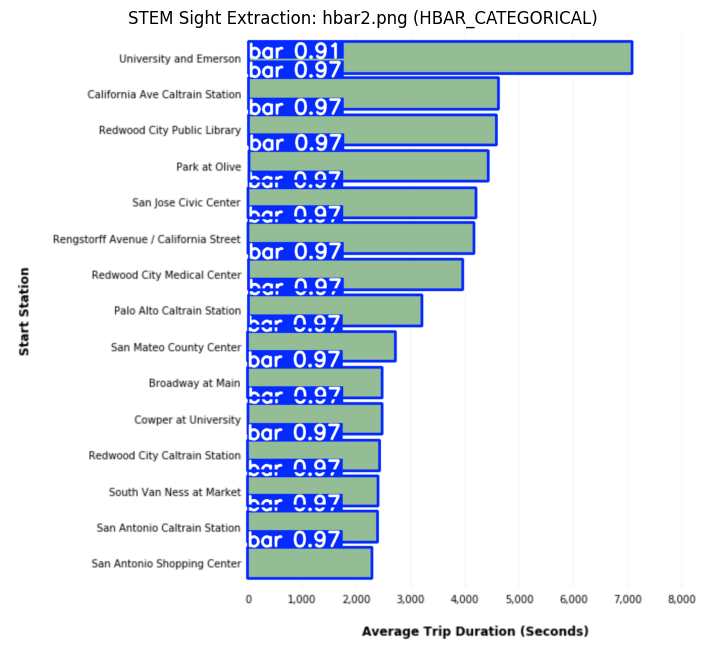

In [31]:
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
from ultralytics import YOLO
import easyocr
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# Suppress annoying Mac/MPS warnings to keep the terminal clean
warnings.filterwarnings("ignore")

# ==========================================
# 1. LOAD ALL AI MODELS
# ==========================================
print("🧠 Booting up STEM Sight AI Models...")

# A. Chart Classifier
classifier = models.resnet18() 
classifier.fc = torch.nn.Linear(classifier.fc.in_features, 5)  
classifier.load_state_dict(torch.load('graph_classifier_real.pth', map_location='cpu'))
classifier.eval()
CLASS_NAMES = ['vbar_categorical', 'hbar_categorical', 'line', 'pie', 'dot_line'] 
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# B. YOLO Bar Detector
yolo_model = YOLO("./train2/weights/best.pt") # Update path if needed

# C. OCR Text Reader
ocr_reader = easyocr.Reader(['en'], gpu=True)


# ==========================================
# 2. THE EXTRACTION ENGINE
# ==========================================
def extract_full_chart_data(image_path):
    print(f"\n🚀 Analyzing: {image_path}")
    print("-" * 40)
    
    # --- STEP 1: Classify Chart Type ---
    img_pil = Image.open(image_path).convert('RGB')
    img_tensor = transform(img_pil).unsqueeze(0)
    with torch.no_grad():
        outputs = classifier(img_tensor)
        _, predicted = torch.max(outputs, 1)
        chart_type = CLASS_NAMES[predicted.item()]
    print(f"📊 Type Detected: {chart_type.upper()}")

    # --- STEP 2: Detect Bars (YOLO) ---
    results = yolo_model(image_path, conf=0.8, iou=0.4, imgsz=1024, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()
    
    if len(boxes) == 0:
        print("❌ No bars detected.")
        return
        
    # --- STEP 3: Read Text & Numbers (OCR) ---
    ocr_results = ocr_reader.readtext(image_path)
    numbers = []
    text_labels = []
    
    for (bbox, text, prob) in ocr_results:
        # Calculate center coordinates of the text box
        cx = (bbox[0][0] + bbox[1][0]) / 2
        cy = (bbox[0][1] + bbox[2][1]) / 2
        clean_text = text.replace(',', '').replace('.', '').strip()
        
        if clean_text.isdigit():
            numbers.append({'val': float(clean_text), 'x': cx, 'y': cy})
        else:
            text_labels.append({'text': text, 'x': cx, 'y': cy})

    # --- STEP 4: Process based on Chart Type ---
    final_data = []
    
    if 'hbar' in chart_type.lower():
        # Calculate Scale Ratio from X-axis numbers 
        axis_nums = sorted([n for n in numbers if n['y'] > boxes[:, 3].max() - 50], key=lambda d: d['x'])
        if len(axis_nums) >= 2:
            units_per_pixel = (axis_nums[-1]['val'] - axis_nums[0]['val']) / (axis_nums[-1]['x'] - axis_nums[0]['x'])
        else:
            print("⚠️ Not enough axis numbers found. Defaulting to 1 pixel = 1 unit.")
            units_per_pixel = 1.0

        # Sort bars Top-to-Bottom
        sorted_boxes = sorted(boxes, key=lambda b: b[1])
        
        for box in sorted_boxes:
            x1, y1, x2, y2 = box
            bar_cy = (y1 + y2) / 2
            pixel_val = x2 - x1
            if pixel_val < 10 or (y2-y1) < 5: continue # Sanity Filter
            
            # Find the closest text label on the left side of the bar
            possible_labels = [l for l in text_labels if l['x'] < x1]
            if possible_labels:
                best_label = min(possible_labels, key=lambda l: abs(l['y'] - bar_cy))
                label_text = best_label['text']
            else:
                label_text = "Unknown Category"
                
            real_val = pixel_val * units_per_pixel
            final_data.append((label_text, int(round(real_val))))

    elif 'vbar' in chart_type.lower():
        # Calculate Scale Ratio from Y-axis numbers
        axis_nums = sorted([n for n in numbers if n['x'] < boxes[:, 0].min() + 50], key=lambda d: d['y'], reverse=True)
        if len(axis_nums) >= 2:
            units_per_pixel = abs((axis_nums[-1]['val'] - axis_nums[0]['val']) / (axis_nums[-1]['y'] - axis_nums[0]['y']))
        else:
            print("⚠️ Not enough axis numbers found. Defaulting to 1 pixel = 1 unit.")
            units_per_pixel = 1.0

        # Sort bars Left-to-Right
        sorted_boxes = sorted(boxes, key=lambda b: b[0])
        
        for box in sorted_boxes:
            x1, y1, x2, y2 = box
            bar_cx = (x1 + x2) / 2
            pixel_val = y2 - y1
            if pixel_val < 10 or (x2-x1) < 5: continue # Sanity Filter
            
            # Find the closest text label below the bar
            possible_labels = [l for l in text_labels if l['y'] > y2]
            if possible_labels:
                best_label = min(possible_labels, key=lambda l: abs(l['x'] - bar_cx))
                label_text = best_label['text']
            else:
                label_text = "Unknown Category"
                
            real_val = pixel_val * units_per_pixel
            final_data.append((label_text, int(round(real_val))))

    else:
        print("⚠️ Not a bar chart.")
        return

    # --- FINAL OUTPUT TEXT ---
    print("\n📈 FINAL EXTRACTED DATA:")
    for label, value in final_data:
        print(f"  {label}: {value}")
        
    # --- DISPLAY THE GRAPH WITH YOLO BOXES ---
    annotated_img = results[0].plot() 
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img_rgb)
    
    # Extract filename for the title
    file_name = os.path.basename(image_path)
    plt.title(f"STEM Sight Extraction: {file_name} ({chart_type.upper()})")
    plt.axis('off')
    plt.show()

    return final_data

# ==========================================
# 3. RUN THE ENGINE
# ==========================================
my_image = "./Real_Test_Graph/hbar2.png" 
extracted_results = extract_full_chart_data(my_image)